In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 291 files belonging to 4 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


Loading Model

In [4]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

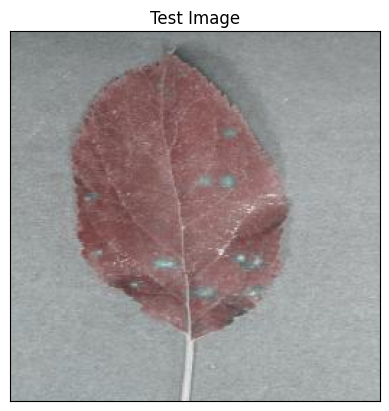

In [5]:
#Test Image Visualization
import cv2
image_path = 'test/appleCiderRust.jpg.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

Testing Model

In [6]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


In [7]:
print(predictions)

[[3.0259014e-06 1.1271104e-06 9.9996090e-01 3.4995330e-05]]


In [8]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


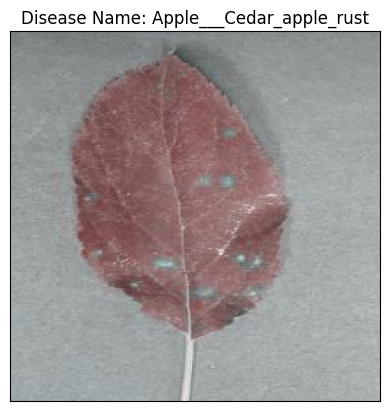

In [9]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [16]:
def check_image_quality(image):
    """Check if image contains valid leaf content"""
    try:
        # Convert PIL Image to numpy array
        if isinstance(image, Image.Image):
            img_array = np.array(image)
        else:
            img_array = image
            
        # Check image dimensions
        if img_array.shape[0] < 50 or img_array.shape[1] < 50:
            return False, "Image is too small (minimum 50x50 pixels)"
        
        # Check for extremely dark or bright images
        mean_brightness = np.mean(img_array)
        if mean_brightness < 30:
            return False, "Image is too dark. Please use better lighting."
        if mean_brightness > 230:
            return False, "Image is too bright or overexposed."
        
        # Check for uniform images (like solid colors or noise)
        std_brightness = np.std(img_array)
        if std_brightness < 15:
            return False, "Image appears to be uniform (solid color or noise)"
        
        # Check if image has green color (common in leaves)
        if len(img_array.shape) == 3:
            green_channel = img_array[:, :, 1]
            avg_green = np.mean(green_channel)
            if avg_green < 30:
                return False, "Image doesn't appear to contain green leaves"
        
        # Check for blurriness using Laplacian variance
        if len(img_array.shape) == 3:
            gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_array
        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        if laplacian_var < 50:
            return False, "Image is too blurry. Please take a clearer photo."
        
        return True, "Image quality is acceptable"
        
    except Exception as e:
        return False, f"Error checking image: {e}"

In [17]:
# Test the quality check function
from PIL import Image
import cv2
import numpy as np

# Copy your check_image_quality function here (the one from main.py)
# Then test it:

# Test with your existing image
image_path = 'test/appleCiderRust.jpg.JPG'
img = Image.open(image_path)
is_valid, message = check_image_quality(img)

if is_valid:
    print(f"✅ Image passed: {message}")
else:
    print(f"❌ Image failed: {message}")

✅ Image passed: Image quality is acceptable
